# ToA 粒子轨迹提取工作流

本笔记演示如何从 ToA 探测器文本数据中提取粒子轨迹并保存为独立的 32×32 矩阵。

## 处理流程
1. 遍历输入目录下所有子文件夹中的 txt 文件
2. 加载 256×256 浮点矩阵
3. 加载坏像素掩码（基于空置探测器数据）
4. 使用 8 邻域连通性检测激活像素区域
5. 筛选轨迹：剔除边缘轨迹、坏像素污染轨迹、超尺寸轨迹
6. 将每个连通区域居中放置于目标尺寸矩阵
7. 保存为 txt 文件，保留六位小数精度

## 1. 路径配置

设置输入目录与输出目录，输出目录将保持与输入相同的子文件夹结构。

In [1]:
from pathlib import Path

# TODO: 修改以下路径以匹配实际的输入与输出位置
INPUT_DIR = Path(r"d:\Project\Timepix\OriginalData\C2")
OUTPUT_DIR = Path(r"d:\Project\Timepix\ProcessData\C2_Original")

# 坏像素掩码文件（空置探测器状态下采集的 ToA 数据）
BAD_PIXEL_FILE = Path(r"D:\Project\Timepix\OriginalData\C2\85\C_r00000_0000.txt")

TARGET_MATRIX_SIZE = 100  # 输出矩阵尺寸
DECIMAL_PRECISION = 6     # 输出小数精度

print(f"输入目录: {INPUT_DIR}")
print(f"输出目录: {OUTPUT_DIR}")
print(f"坏像素文件: {BAD_PIXEL_FILE}")
print(f"目标矩阵尺寸: {TARGET_MATRIX_SIZE}×{TARGET_MATRIX_SIZE}")

输入目录: d:\Project\Timepix\OriginalData\C2
输出目录: d:\Project\Timepix\ProcessData\C2_Original
坏像素文件: D:\Project\Timepix\OriginalData\C2\85\C_r00000_0000.txt
目标矩阵尺寸: 100×100


## 2. 加载原始矩阵

读取 txt 文件并解析为 256×256 浮点矩阵。

In [2]:
import numpy as np
from typing import List, Tuple, Dict


def load_detector_matrix(file_path: Path) -> np.ndarray:
    """加载探测器数据文件为 256×256 浮点矩阵。
    
    Args:
        file_path: txt 文件路径
        
    Returns:
        256×256 的 float64 矩阵
        
    Raises:
        ValueError: 如果矩阵尺寸不是 256×256
    """
    matrix = np.loadtxt(file_path, dtype=np.float64)
    if matrix.shape != (256, 256):
        raise ValueError(f"矩阵尺寸错误: 期望 (256, 256)，实际 {matrix.shape}")
    return matrix


def list_txt_files(input_dir: Path) -> List[Path]:
    """递归列出目录下所有 txt 文件。
    
    Args:
        input_dir: 输入目录
        
    Returns:
        txt 文件路径列表
    """
    return sorted(input_dir.rglob("*.txt"))

## 3. 坏像素掩码加载

从空置探测器数据中提取坏像素坐标集合。这些像素在无粒子状态下仍保持激活，属于损坏像素。

In [3]:
def load_bad_pixel_mask(file_path: Path) -> set:
    """加载坏像素掩码文件，提取坏像素坐标集合。
    
    坏像素定义：空置探测器状态下仍激活的像素（值 > 0）。
    
    Args:
        file_path: 空置探测器 ToA 数据文件路径
        
    Returns:
        坏像素坐标集合 {(row, col), ...}
    """
    matrix = np.loadtxt(file_path, dtype=np.float64)
    if matrix.shape != (256, 256):
        raise ValueError(f"坏像素掩码尺寸错误: 期望 (256, 256)，实际 {matrix.shape}")
    
    # 提取所有非零像素的坐标
    bad_coords = set(zip(*np.where(matrix > 0)))
    return bad_coords


# 加载坏像素掩码
bad_pixel_coords = load_bad_pixel_mask(BAD_PIXEL_FILE)
print(f"检测到 {len(bad_pixel_coords)} 个坏像素")

检测到 30 个坏像素


## 4. 连通区域检测

使用 8 邻域 BFS 算法检测激活像素的连通区域，记录每个区域的坐标和边界信息。

In [4]:
from scipy import ndimage

# 8 邻域结构元素
STRUCTURE_8_CONNECTED = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1],
], dtype=np.int32)


def extract_connected_components(matrix: np.ndarray) -> List[Dict]:
    """提取矩阵中所有激活像素的连通区域。
    
    使用 scipy.ndimage.label 进行 8 邻域连通性检测（C 实现，高性能）。
    
    Args:
        matrix: 256×256 浮点矩阵
        
    Returns:
        连通区域列表，每个区域包含:
        - coords: 像素坐标列表 [(row, col), ...]
        - values: 对应的像素值列表
        - row_min, row_max, col_min, col_max: 边界框
        - height, width: 区域尺寸
    """
    mask = matrix > 0  # 激活像素掩码

    # 使用 scipy 的高效连通区域标记
    labeled_array, num_features = ndimage.label(mask, structure=STRUCTURE_8_CONNECTED)

    if num_features == 0:
        return []

    components = []

    # 使用 find_objects 获取每个区域的边界切片（高效）
    slices = ndimage.find_objects(labeled_array)

    for label_id, slc in enumerate(slices, start=1):
        if slc is None:
            continue

        row_slice, col_slice = slc
        row_min, row_max = row_slice.start, row_slice.stop - 1
        col_min, col_max = col_slice.start, col_slice.stop - 1

        # 提取该区域的坐标和值
        region_mask = labeled_array[slc] == label_id
        local_coords = np.argwhere(region_mask)

        # 转换为全局坐标
        coords = [(r + row_min, c + col_min) for r, c in local_coords]
        values = [matrix[r, c] for r, c in coords]

        height = row_max - row_min + 1
        width = col_max - col_min + 1

        components.append({
            "coords": coords,
            "values": values,
            "coords_set": set(coords),  # 预计算集合，加速后续检查
            "row_min": row_min,
            "row_max": row_max,
            "col_min": col_min,
            "col_max": col_max,
            "height": height,
            "width": width,
        })

    return components

## 5. 轨迹筛选与居中

定义筛选函数（边缘检测、坏像素交集检测、尺寸检测）和居中渲染函数。

In [5]:
def check_component_size(component: Dict, target_size: int = TARGET_MATRIX_SIZE) -> bool:
    """检查连通区域是否能放入目标矩阵。
    
    Args:
        component: 连通区域字典
        target_size: 目标矩阵尺寸
        
    Returns:
        True 如果区域可以放入目标矩阵，否则 False
    """
    return component["height"] <= target_size and component["width"] <= target_size


def is_on_detector_edge(component: Dict, matrix_size: int = 256) -> bool:
    """检查连通区域是否触及探测器边缘（优化版）。
    
    使用边界框快速判断，避免遍历所有坐标。
    
    Args:
        component: 连通区域字典
        matrix_size: 探测器矩阵尺寸，默认 256
        
    Returns:
        True 如果轨迹触及边缘（不完整），否则 False
    """
    edge_max = matrix_size - 1
    # 使用边界框快速判断
    if (component["row_min"] == 0 or component["row_max"] == edge_max or
        component["col_min"] == 0 or component["col_max"] == edge_max):
        return True
    return False


def has_bad_pixel_intersection(component: Dict, bad_pixel_coords: set) -> bool:
    """检查连通区域是否与坏像素有交集（优化版）。
    
    使用集合交集操作，时间复杂度 O(min(m, n))。
    
    Args:
        component: 连通区域字典，包含 coords_set
        bad_pixel_coords: 坏像素坐标集合 {(row, col), ...}
        
    Returns:
        True 如果轨迹与坏像素有交集（受污染），否则 False
    """
    # 使用预计算的集合进行快速交集判断
    return bool(component["coords_set"] & bad_pixel_coords)


def render_centered_matrix(
    component: Dict,
    target_size: int = TARGET_MATRIX_SIZE
) -> np.ndarray:
    """将连通区域居中渲染到目标尺寸矩阵（优化版）。
    
    使用 NumPy 向量化操作替代 Python 循环。
    
    Args:
        component: 连通区域字典，包含 coords 和 values
        target_size: 目标矩阵尺寸
        
    Returns:
        target_size × target_size 的浮点矩阵
    """
    coords = np.array(component["coords"], dtype=np.int32)
    values = np.array(component["values"], dtype=np.float64)
    
    # 计算区域质心
    centroid_row = coords[:, 0].mean()
    centroid_col = coords[:, 1].mean()
    
    # 计算平移量，使质心位于画布中心
    center = (target_size - 1) / 2.0
    shift_row = int(round(center - centroid_row))
    shift_col = int(round(center - centroid_col))
    
    # 计算新坐标
    new_rows = coords[:, 0] + shift_row
    new_cols = coords[:, 1] + shift_col
    
    # 筛选有效坐标
    valid_mask = (
        (new_rows >= 0) & (new_rows < target_size) &
        (new_cols >= 0) & (new_cols < target_size)
    )
    
    # 创建画布并使用向量化赋值
    canvas = np.zeros((target_size, target_size), dtype=np.float64)
    canvas[new_rows[valid_mask], new_cols[valid_mask]] = values[valid_mask]
    
    return canvas

## 6. 文件保存

将提取的轨迹矩阵保存为 txt 文件，保留六位小数精度。

In [ ]:
def build_output_filename(original_stem: str, track_index: int) -> str:
    """生成输出文件名。
    
    Args:
        original_stem: 原始文件名（不含扩展名）
        track_index: 轨迹序号（从 1 开始）
        
    Returns:
        输出文件名，格式: 原文件名_001.txt
    """
    return f"{original_stem}_{track_index:03d}.txt"


def save_matrix(
    matrix: np.ndarray,
    file_path: Path,
    precision: int = DECIMAL_PRECISION
) -> None:
    """保存矩阵为 txt 文件。
    
    Args:
        matrix: 要保存的矩阵
        file_path: 输出文件路径
        precision: 小数精度
    """
    file_path.parent.mkdir(parents=True, exist_ok=True)
    fmt = f"%.{precision}f"
    np.savetxt(file_path, matrix, fmt=fmt)

## 7. 批量处理主函数

遍历输入目录，处理所有 txt 文件，提取轨迹并保存。包含三重筛选：
1. 边缘轨迹剔除
2. 坏像素污染轨迹剔除
3. 超尺寸轨迹跳过

In [7]:
def process_all_files(
    input_dir: Path,
    output_dir: Path,
    bad_pixel_coords: set,
    target_size: int = TARGET_MATRIX_SIZE,
    precision: int = DECIMAL_PRECISION,
    print_every: int = 200,
) -> Dict[str, int]:
    """批量处理目录下所有 txt 文件。

    说明：为排查性能波动，可暂时不使用进度条，仅每隔一定数量输出一次进度。

    Args:
        input_dir: 输入目录
        output_dir: 输出目录
        bad_pixel_coords: 坏像素坐标集合
        target_size: 目标矩阵尺寸
        precision: 输出小数精度
        print_every: 每处理多少个文件打印一次进度

    Returns:
        统计信息字典
    """
    stats = {
        "total_files": 0,
        "saved_tracks": 0,
        "oversized_tracks": 0,
        "edge_tracks": 0,
        "bad_pixel_tracks": 0,
        "empty_files": 0,
    }

    txt_files = list_txt_files(input_dir)
    print(f"找到 {len(txt_files)} 个 txt 文件")
    print(f"坏像素数量: {len(bad_pixel_coords)}")

    for i, file_path in enumerate(txt_files, start=1):
        stats["total_files"] += 1

        if print_every > 0 and (i == 1 or i % print_every == 0):
            print(f"进度: {i}/{len(txt_files)}")

        try:
            matrix = load_detector_matrix(file_path)
        except Exception as e:
            print(f"警告: 无法加载文件 {file_path}: {e}")
            continue

        # 提取连通区域
        components = extract_connected_components(matrix)

        if not components:
            stats["empty_files"] += 1
            continue

        # 计算输出相对路径
        rel_path = file_path.parent.relative_to(input_dir)
        original_stem = file_path.stem

        # 处理每个连通区域
        track_index = 0
        for component in components:
            # 检查 1: 是否触及探测器边缘（轨迹不完整）
            if is_on_detector_edge(component):
                stats["edge_tracks"] += 1
                continue

            # 检查 2: 是否与坏像素有交集（受污染）
            if has_bad_pixel_intersection(component, bad_pixel_coords):
                stats["bad_pixel_tracks"] += 1
                continue

            # 检查 3: 尺寸是否超过目标
            if not check_component_size(component, target_size):
                print(
                    f"警告: 文件 {file_path.name} 中的轨迹尺寸 "
                    f"({component['height']}×{component['width']}) 超过 {target_size}×{target_size}，已跳过"
                )
                stats["oversized_tracks"] += 1
                continue

            track_index += 1

            # 生成居中矩阵
            centered_matrix = render_centered_matrix(component, target_size)

            # 保存
            output_filename = build_output_filename(original_stem, track_index)
            output_path = output_dir / rel_path / output_filename
            save_matrix(centered_matrix, output_path, precision)
            stats["saved_tracks"] += 1

    return stats

## 8. 执行批量处理

确认路径配置正确后，运行以下单元格启动批处理。

In [8]:
# 执行批量处理
stats = process_all_files(INPUT_DIR, OUTPUT_DIR, bad_pixel_coords)

print("\n========== 处理完成 ==========")
print(f"处理文件总数: {stats['total_files']}")
print(f"保存轨迹数量: {stats['saved_tracks']}")
print(f"边缘轨迹剔除: {stats['edge_tracks']}")
print(f"坏像素轨迹剔除: {stats['bad_pixel_tracks']}")
print(f"超尺寸轨迹数: {stats['oversized_tracks']}")
print(f"空文件数量:   {stats['empty_files']}")

找到 2162 个 txt 文件
坏像素数量: 30
进度: 1/2162
进度: 200/2162
进度: 400/2162
进度: 600/2162
进度: 800/2162
进度: 1000/2162
进度: 1200/2162
进度: 1400/2162
进度: 1600/2162
进度: 1800/2162
进度: 2000/2162

========== 处理完成 ==========
处理文件总数: 2162
保存轨迹数量: 629758
边缘轨迹剔除: 50092
坏像素轨迹剔除: 6305
超尺寸轨迹数: 0
空文件数量:   0


## 9. 可视化验证（可选）

随机抽取部分提取结果进行可视化验证。

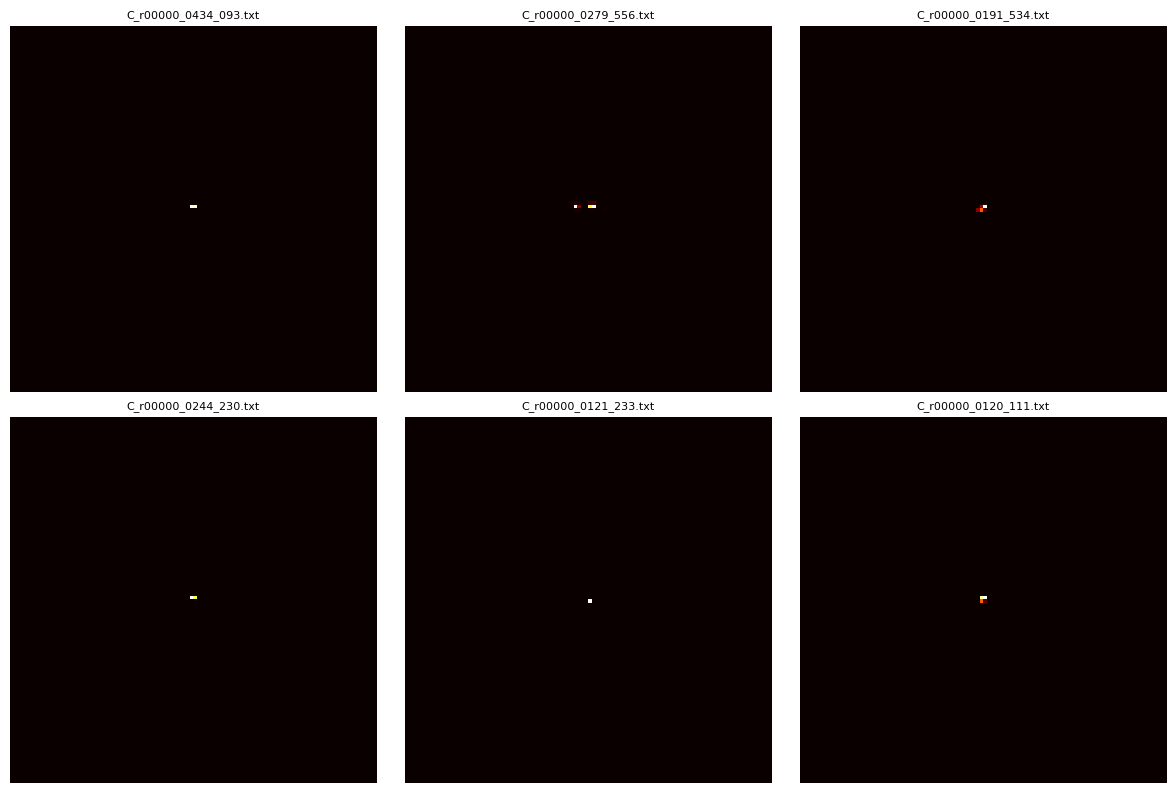

In [9]:
import matplotlib.pyplot as plt
import random


def visualize_samples(output_dir: Path, num_samples: int = 6):
    """随机可视化部分提取结果。"""
    all_files = list(output_dir.rglob("*.txt"))
    if not all_files:
        print("未找到输出文件")
        return
    
    samples = random.sample(all_files, min(num_samples, len(all_files)))
    
    cols = 3
    rows = (len(samples) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    
    for ax, file_path in zip(axes, samples):
        matrix = np.loadtxt(file_path)
        ax.imshow(matrix, cmap='hot', interpolation='nearest')
        ax.set_title(file_path.name, fontsize=8)
        ax.axis('off')
    
    # 隐藏多余的子图
    for ax in axes[len(samples):]:
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()


# 可视化
visualize_samples(OUTPUT_DIR)